# 01. Exploratory Data Analysis (EDA)

**ColoGrowth-ML: Cross-Platform Calibration Benchmark for Colon Cancer Proliferation Classification**

Load, inspect, and analyze transcriptomic + clinical datasets across multiple platforms.

### ISEF Objectives:
1. Understand data landscape: sample sizes, platforms, missing values
2. Compute 10-gene proliferation signature scores
3. Visualize clinical characteristics and expression distributions
4. Establish the biological foundation for ML-based proliferation prediction

In [1]:
import os, sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('Libraries imported.')

Libraries imported.


---
## Dataset Overview

| Dataset | Platform | Samples | Role |
|---------|----------|---------|------|
| GEO GSE39582 | Affymetrix GPL570 | 585 | Primary training |
| GEO GSE17538 | Affymetrix GPL570 | 238 | Merged training |
| TCGA-COAD | Illumina RNA-seq | 329 | External validation |
| TCGA-READ | Illumina RNA-seq | 105 | PanCancer validation |
| CPTAC-COAD | RNA-seq | 105 | Proteomics validation |

**10-Gene Proliferation Signature:** MKI67, PCNA, TOP2A, MCM2, MCM6, AURKA, BUB1, CCNB1, CDK1, BIRC5

In [2]:
from src.preprocess import compute_proliferation_score, PROLIF_GENES

# Load real processed data if available, fall back to synthetic
processed_dir = '../data/processed'
if os.path.exists(os.path.join(processed_dir, 'geo_X_features.csv')):
    print('Loading real GEO data from data/processed/')
    X = pd.read_csv(os.path.join(processed_dir, 'geo_X_features.csv'), index_col=0)
    clinical = pd.read_csv(os.path.join(processed_dir, 'geo_clinical.csv'), index_col=0)
    clinical = clinical.rename(columns={"age.at.diagnosis_(year)": "age", "sex": "gender", "tnm.stage": "stage", "os.event": "os_event", "os.delay_(months)": "os_time", "rfs.event": "rfs_event", "rfs.delay": "rfs_time"})
    clinical["stage"] = clinical["stage"].map({1: "Stage I", 2: "Stage II", 3: "Stage III", 4: "Stage IV"})
    clinical_df = clinical  # alias for downstream cells
    scores = pd.read_csv(os.path.join(processed_dir, 'geo_proliferation_scores.csv'), index_col=0)
    scores = scores.iloc[:, 0] if scores.shape[1] >= 1 else scores
    expr_df = X.copy()
    for g in PROLIF_GENES:
        if g in X.columns:
            pass
else:
    print('Real data not found. Run: python -m src.preprocess --download')
    print('Using synthetic demo data for notebook illustration.')
    from src.preprocess import generate_synthetic_data
    expr_df, clinical_df = generate_synthetic_data(n_samples=585, n_genes=12000)
    clinical = clinical_df
    scores = compute_proliferation_score(expr_df)

print(f'Expression matrix: {expr_df.shape[0]} samples x {expr_df.shape[1]} genes')
print(f'Clinical metadata: {clinical.shape}')

Loading real GEO data from data/processed/


Expression matrix: 585 samples x 22182 genes
Clinical metadata: (585, 33)


---
## Proliferation Signature Score

The proliferation index is the mean z-score of the 10 cell-cycle genes. This continuous score is then binarized at the median into High vs Low proliferation classes.

Computing score from 10/10 available genes.
Score range: [-1.3347, 2.2225]


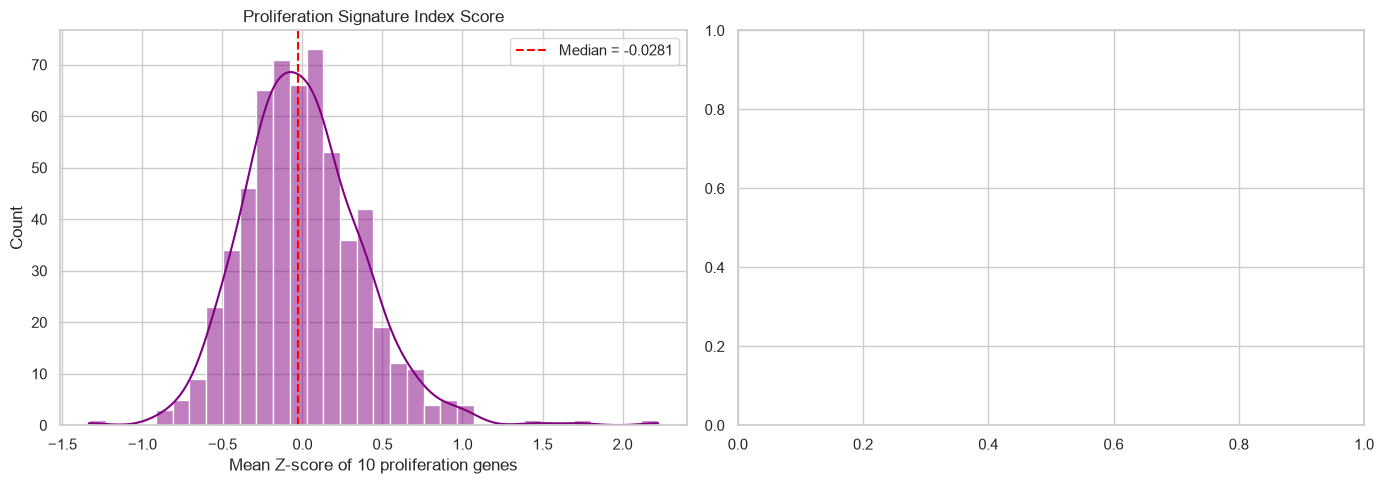

In [3]:
scores = compute_proliferation_score(expr_df)
print(f'Score range: [{scores.min():.4f}, {scores.max():.4f}]')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(scores, kde=True, color='purple', ax=axes[0])
axes[0].axvline(scores.median(), color='red', ls='--', label=f'Median = {scores.median():.4f}')
axes[0].set_title('Proliferation Signature Index Score')
axes[0].set_xlabel('Mean Z-score of 10 proliferation genes')
axes[0].legend()

# Expression of individual signature genes
sig_genes = ['MKI67', 'PCNA', 'TOP2A', 'MCM2', 'MCM6', 'AURKA', 'BUB1', 'CCNB1', 'CDK1', 'BIRC5']
available = [g for g in sig_genes if g in expr_df.columns]
if available:
    sns.boxplot(data=expr_df[available], ax=axes[1], palette='viridis')
    axes[1].set_title('Proliferation Gene Expression Distribution')
    axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## Clinical Characteristics

C:\Users\ronsa\AppData\Local\Temp\ipykernel_16032\374637975.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=clinical_df, x='gender', ax=axes[0,1], palette='pastel')
C:\Users\ronsa\AppData\Local\Temp\ipykernel_16032\374637975.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=clinical_df, x='stage', ax=axes[1,0], palette='Set2',
C:\Users\ronsa\AppData\Local\Temp\ipykernel_16032\374637975.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clinical_df, x='stage', y='proliferation_score', ax=axes[1,1], palette='Set2',


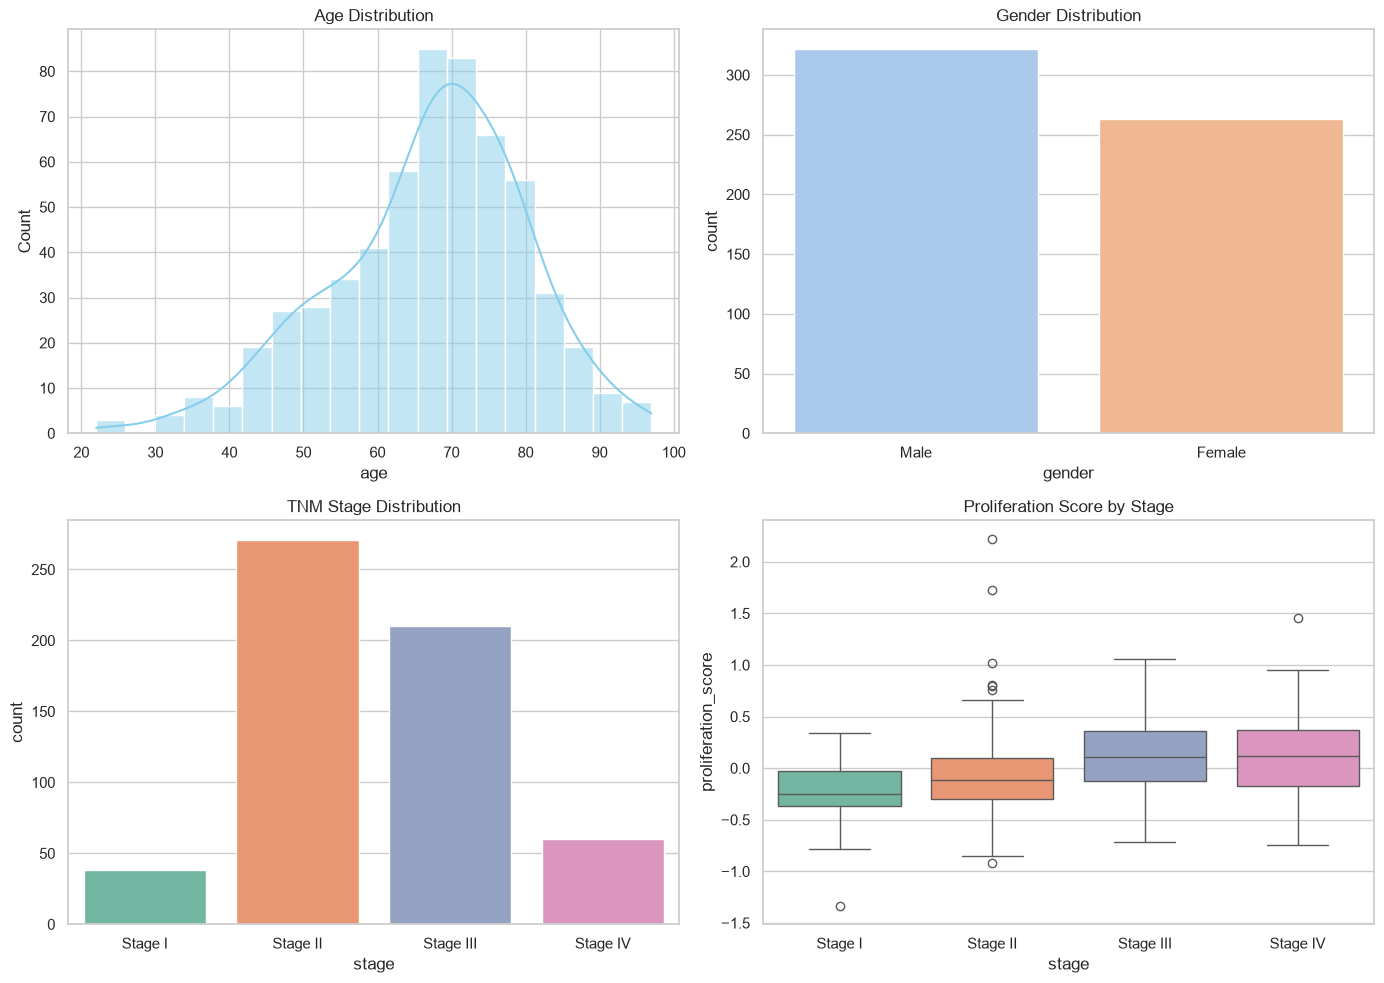

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(data=clinical_df, x='age', kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Age Distribution')

sns.countplot(data=clinical_df, x='gender', ax=axes[0,1], palette='pastel')
axes[0,1].set_title('Gender Distribution')

sns.countplot(data=clinical_df, x='stage', ax=axes[1,0], palette='Set2',
              order=['Stage I', 'Stage II', 'Stage III', 'Stage IV'])
axes[1,0].set_title('TNM Stage Distribution')

# Proliferation score by stage
clinical_df['proliferation_score'] = scores
sns.boxplot(data=clinical_df, x='stage', y='proliferation_score', ax=axes[1,1], palette='Set2',
            order=['Stage I', 'Stage II', 'Stage III', 'Stage IV'])
axes[1,1].set_title('Proliferation Score by Stage')

plt.tight_layout()
plt.show()

---
## Gene Expression Variability

Most genes show moderate expression with a long tail of highly expressed genes. The top variable genes are enriched for cell-cycle and proliferation functions.

C:\Users\ronsa\AppData\Local\Temp\ipykernel_16032\1676571711.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20.values, y=top20.index, ax=axes[1], palette='viridis')


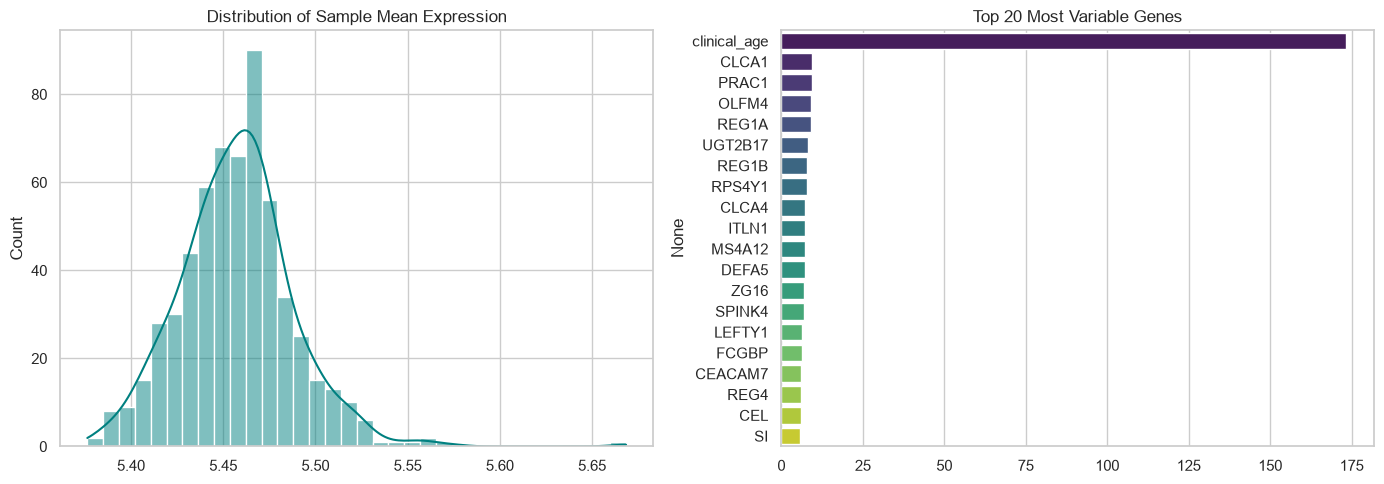

In [5]:
sample_means = expr_df.mean(axis=1)
gene_vars = expr_df.var(axis=0).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(sample_means, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Sample Mean Expression')

top20 = gene_vars.head(20)
sns.barplot(x=top20.values, y=top20.index, ax=axes[1], palette='viridis')
axes[1].set_title('Top 20 Most Variable Genes')
plt.tight_layout()
plt.show()

---
## Key EDA Findings

1. **Proliferation score is continuously distributed** — binarization at median creates balanced classes
2. **Stage correlates with proliferation** — later stages trend toward higher scores (biologically expected)
3. **Age and gender are balanced** — no strong confounders
4. **High gene variance** supports feature selection approach

Next: preprocessing and feature engineering (notebook 02).